In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


cutoff_churn = 50

customers = pd.read_csv("customers.csv")
loyalty_members = pd.read_csv("loyalty_members.csv")
orders = pd.read_csv("orders.csv")
order_details = pd.read_csv("order_details.csv")
food_menu = pd.read_csv("food_menu.csv")
drinks_menu = pd.read_csv("drinks_menu.csv")
games_menu = pd.read_csv("games_menu.csv")


orders["transaction_date"] = pd.to_datetime(orders["transaction_date"], errors="coerce")

In [2]:
#Combining all menu files
food_menu["category"] = "food"
drinks_menu["category"] = "drink"
games_menu["category"] = "game"

food_menu.rename(columns={"id": "item_id"}, inplace=True)
drinks_menu.rename(columns={"id": "item_id"}, inplace=True)
games_menu.rename(columns={"id": "item_id"}, inplace=True)

menu_lookup = pd.concat([food_menu, drinks_menu, games_menu], ignore_index=True)
menu_lookup = menu_lookup[["item_id", "name", "category"]].rename(columns={"name": "item_name"})

In [3]:
#Find last visit and churn label
last_visit = orders.groupby("email")["transaction_date"].max().reset_index()
last_visit.rename(columns={"transaction_date": "last_visit_date"}, inplace=True)
ref_date = orders["transaction_date"].max()
last_visit["days_since_last_visit"] = (ref_date - last_visit["last_visit_date"]).dt.days
last_visit["churn"] = (last_visit["days_since_last_visit"] > cutoff_churn).astype(int)

#Joining order details with orders and menu
lines = order_details[["transaction_id", "item_id", "line_amount_cad"]].merge(
    orders[["transaction_id", "email"]], on="transaction_id", how="left"
)
lines = lines.merge(menu_lookup[["item_id", "category"]], on="item_id", how="left")


In [4]:
#Customer spending by category

cust_spend = lines.groupby(["email", "category"])["line_amount_cad"].sum().reset_index()
wide = cust_spend.pivot(index="email", columns="category", values="line_amount_cad").fillna(0).reset_index()
for col in ["food", "drink", "game"]:
    if col not in wide.columns:
        wide[col] = 0
wide["total_spend"] = wide["food"] + wide["drink"] + wide["game"]
wide["ratio_food"] = wide["food"] / wide["total_spend"].replace(0, np.nan)
wide["ratio_drink"] = wide["drink"] / wide["total_spend"].replace(0, np.nan)
wide["ratio_game"] = wide["game"] / wide["total_spend"].replace(0, np.nan)
wide = wide.fillna(0)



In [5]:
#Merging the last visit with churn info
merged = last_visit.merge(wide, on="email", how="left").fillna(0)
avg_spend = merged.groupby("churn")[["food", "drink", "game"]].mean()

print("\nAverage spend by churn:")
print(avg_spend)




Average spend by churn:
             food       drink        game
churn                                    
0      281.323553  241.388911  269.312579
1      256.970199  206.507616  238.409669


In [6]:
#Churned customers table
churned = last_visit[last_visit["churn"] == 1][["email", "last_visit_date"]]
churned_txn = orders.merge(churned, on="email", how="inner")[["transaction_id", "email"]]
churned_lines = order_details.merge(churned_txn, on="transaction_id", how="inner")



In [7]:
#Top items purchased by churned customers
item_stats = churned_lines.groupby("item_id")["line_amount_cad"].sum().reset_index()
item_stats = item_stats.merge(menu_lookup, on="item_id", how="left")
item_stats = item_stats.sort_values("line_amount_cad", ascending=False)
print("\nTop items (revenue, churned customers):")
print(item_stats.head(10))




Top items (revenue, churned customers):
   item_id  line_amount_cad           item_name category
10    E002         12160.00   Arcade Credits 40     game
6     D007          6502.18       Old Fashioned    drink
5     D006          6469.82           Margarita    drink
9     E001          6200.00   Arcade Credits 20     game
12    E004          5112.00      Billiards Hour     game
4     D005          4995.00      House Wine 6oz    drink
11    E003          4706.86       VR Experience     game
23    F008          4276.51      Steak Sandwich     food
20    F005          4174.26  BBQ Ribs Half Rack     food
3     D004          4151.61     Draft Beer Pint    drink


In [29]:
#Items purchased in last visits
churned_orders = orders.merge(churned, on="email", how="inner")
last_txn = churned_orders[churned_orders["transaction_date"] == churned_orders["last_visit_date"]]
last_lines = order_details.merge(last_txn[["transaction_id"]], on="transaction_id", how="inner")

count_last_items = last_lines.groupby("item_id")["transaction_id"].nunique().reset_index()
count_last_items.rename(columns={"transaction_id": "num_churned_last_transaction"}, inplace=True)
count_last_items = count_last_items.merge(menu_lookup, on="item_id", how="left")
print("\nMost common last-visit items (churned):")
print(count_last_items.sort_values("num_churned_last_transaction", ascending=False).head(10))




Most common last-visit items (churned):
   item_id  num_churned_last_transaction          item_name category
0     D001                            58         Soft Drink    drink
5     D006                            54          Margarita    drink
6     D007                            45      Old Fashioned    drink
7     D008                            45           Iced Tea    drink
4     D005                            44     House Wine 6oz    drink
3     D004                            43    Draft Beer Pint    drink
2     D003                            41             Coffee    drink
1     D002                            40      Bottled Water    drink
10    E002                            38  Arcade Credits 40     game
14    E006                            36     Skee-Ball Pack     game


In [19]:
#Churnes last visits by weekday
churned = last_visit[last_visit["churn"] == 1].copy()
churned["weekday"] = churned["last_visit_date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
counts = churned["weekday"].value_counts()
weekday_table = pd.DataFrame({"weekday": order})
weekday_table["count"] = weekday_table["weekday"].map(counts).fillna(0).astype(int)

print("\nChurned customers' last visit (weekday)")
print(weekday_table)


Churned customers' last visit (weekday)
     weekday  count
0     Monday     20
1    Tuesday     27
2  Wednesday     12
3   Thursday     24
4     Friday     18
5   Saturday     22
6     Sunday     28


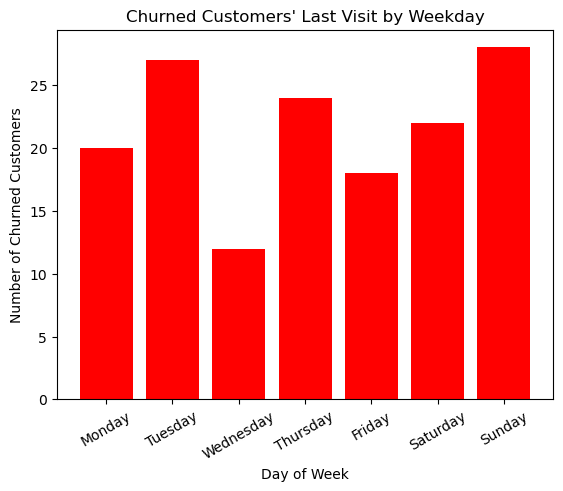

In [21]:
plt.bar(weekday_table["weekday"], weekday_table["count"], color="red")
plt.title("Churned Customers' Last Visit by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Churned Customers")
plt.xticks(rotation=30)
plt.show()

In [30]:
#Monthly table for churned customers
churned["month"] = churned["last_visit_date"].dt.to_period("M").dt.to_timestamp()
churned["year"]  = churned["last_visit_date"].dt.year

monthly_counts = (
    churned[churned["year"].isin([2024, 2025])]
    .groupby(["year", "month"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["year","month"])
)

print("\nChurners' last-visit by month (2024–2025):")
print(monthly_counts)



Churners' last-visit by month (2024–2025):
   year      month  count
0  2025 2025-04-01      2
1  2025 2025-05-01      6
2  2025 2025-06-01     15
3  2025 2025-07-01     19
4  2025 2025-08-01     82
5  2025 2025-09-01     27


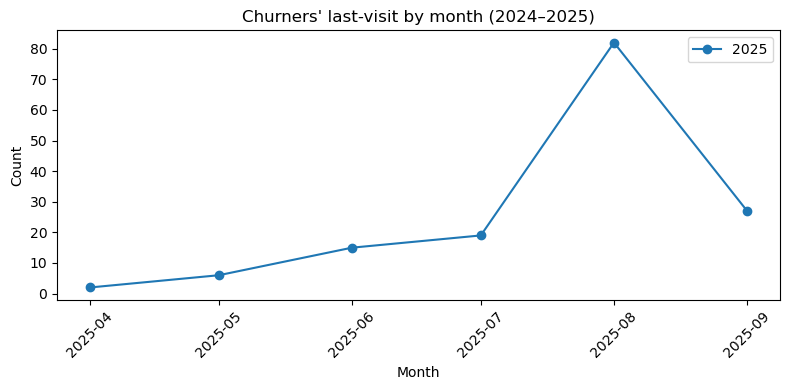

In [28]:
plt.figure(figsize=(8,4))
for y in monthly_counts["year"].unique():
    subset = monthly_counts[monthly_counts["year"] == y]
    plt.plot(subset["month"], subset["count"], marker="o", label=str(y))

plt.title("Churners' last-visit by month (2024–2025)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()